<a href="https://colab.research.google.com/github/SaB-true/DataScienceToolsDeliverable/blob/main/Copia1_de_Family_Office_Fund_Equipo_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from concurrent.futures import ThreadPoolExecutor

In [ ]:
!pip install yfinance
!pip install PyPortfolioOpt
!pip install cvxpy

import time
import numpy as np
import yfinance as yf
import pandas as pd
from datetime import datetime
from datetime import date
from pypfopt import black_litterman, risk_models
from pypfopt.black_litterman import market_implied_prior_returns
from pypfopt.black_litterman import BlackLittermanModel

In [ ]:
# A continuación, la ruta de acceso al dataset con los tickers a analizar
ruta = '/content/drive/MyDrive/RETO GESTION PORTAFOLIOS PYTHON EQUIPO 2/tickers_masterON.xlsx'

df = pd.read_excel(ruta)
df.head()

,Yahoo Ticker,Original Ticker,Country,Industry,Benchmark Ticker,Benchmark Name
0,AAPL,AAPL,USA,Technology (Large Cap),^NDX,NASDAQ-100 Index
1,MSFT,MSFT,USA,Technology (Large Cap),^NDX,NASDAQ-100 Index
2,NVDA,NVDA,USA,Technology (Large Cap),^NDX,NASDAQ-100 Index
3,AVGO,AVGO,USA,Technology (Large Cap),^NDX,NASDAQ-100 Index
4,ORCL,ORCL,USA,Technology (Large Cap),^GSPC,S&P 500 Index


In [ ]:
#Extraeremos los tickers de stocks y de benchmarks
tickers_stocks = df['Yahoo Ticker'].dropna().unique().tolist()
tickers_benchmarks = df['Benchmark Ticker'].dropna().unique().tolist()

# Los juntamos con set() para quedarnos solo con una lista grande que podamos
# usar para la busqueda masiva en yahoo finance
# Esto garantiza que cada benchmark se descargue una sola vez
tickers_totales = list(set(tickers_stocks + tickers_benchmarks))

print(f"Descargamos {len(tickers_totales)} tickers")

Descargamos 1360 tickers


In [ ]:
#Definimos el horizonte temporal (hasta la fecha actual 19 de abril de 2026)
start_date = "2021-01-01"
end_date = date.today().strftime('%Y-%m-%d')

# Descargamos los precios de cierre ('Close') con frecuencia mensual ('1mo')
# '1mo' descarga el precio del primer día de cada mes :D
data = yf.download(
    tickers_totales,
    start=start_date,
    end=end_date,
    interval="1mo"
)['Close']


/tmp/ipykernel_4245/2399118101.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*                      3%                       ]  36 of 1360 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: INCARSOB.MX"}}}
[*********************100%***********************]  1360 of 1360 completed
ERROR:yfinance:
122 Failed downloads:
ERROR:yfinance:['PRFT', 'INCARSOB.MX', 'HES', 'ERF', 'FI', 'ERI', 'PARA', 'FL', 'DRE', 'ARNC', 'KRA', 'FIBRAPL.MX', 'OMN', 'POM.PA', 'BACHOCOB.MX', 'AMAM', 'HA', 'RYDER', 'MWT.AX', 'SNV', 'CIVI', 'DAI.DE', 'ORP.PA', 'MODN', 'WDI.DE', 'SQ2.AX', 'CHK', 'ALL.PA', 'SCB.L', 'JNPR', 'PXD', 'AMSWA', 'TPX', 'SWN', 'MYL', 'IENOVA.MX', 'JWN', 'MEXCHEM.MX', 'STOR', 'SAFM', 'RE', 'CNSL', 'NWG.AX', 'Y', 'THS', 'H24.AX', 'NEX', 'IPG', 'MIME', 'WETF', 'BDEV.L', 'DISH', 'NRW.AX', 'IDP.AX', 'NTCO3.SA', 'SAVE', 'ALFAA.MX', 'HSBC.L', 'SGEN', 

In [ ]:
# Identificamos qué tickers realmente trajeron datos (limpieza de columnas vacías)
data_limpia = data.dropna(axis=1, how='all')

# Informamos cuáles tickers se perdieron
tickers_exitosos = data_limpia.columns.tolist()
tickers_fallidos = list(set(tickers_totales) - set(tickers_exitosos))

print(f"Descarga exitosa: {len(tickers_exitosos)} tickers.")
print(f"Tickers eliminados (deslistados/error): {len(tickers_fallidos)}")

Descarga exitosa: 1238 tickers.
Tickers eliminados (deslistados/error): 123


In [ ]:
#calculamos retornos logarítmicos
log_retornos = np.log(data_limpia).diff()

# borramos la primera fila que sabemos que no tiene datos de retornos:
log_retornos = log_retornos.iloc[1:]

print(f"Dimensiones: {log_retornos.shape}")
print(log_retornos.head())

Dimensiones: (63, 1238)
Ticker        1605.T    3086.T    3099.T    3289.T    3405.T    3407.T  \
Date                                                                     
2021-02-01  0.259180  0.163040  0.190852  0.119474  0.062304 -0.016014   
2021-03-01 -0.036368  0.050028  0.001286 -0.016655  0.057857  0.106276   
2021-04-01 -0.013316 -0.010521 -0.013107 -0.064076 -0.062061 -0.088487   
2021-05-01  0.009339  0.034030  0.029737  0.068444 -0.043916  0.045414   
2021-06-01  0.096155 -0.088364 -0.014112  0.027316 -0.062662  0.012781   

Ticker        3436.T    360.AX    3861.T    4004.T  ...     ^FCHI     ^FTSE  \
Date                                                ...                       
2021-02-01  0.096710  0.123794  0.059880  0.038111  ...  0.054778  0.011776   
2021-03-01  0.038746  0.091567  0.064911  0.194201  ...  0.061871  0.034890   
2021-04-01  0.114346  0.184056 -0.029049  0.049546  ...  0.032791  0.037451   
2021-05-01 -0.108425  0.005186 -0.059808  0.028297  ...  0.027

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [ ]:
# Media aritmética de los retornos logarítmicos (mensual)
retorno_prom_mensual = log_retornos.mean()

# Anualización de los retornos logarítmicos
retorno_prom_anual = retorno_prom_mensual * 12

print(retorno_prom_mensual.head())
print(retorno_prom_anual.head())

Ticker
1605.T    0.033342
3086.T    0.019226
3099.T    0.026734
3289.T    0.016241
3405.T    0.009271
dtype: float64
Ticker
1605.T    0.400107
3086.T    0.230717
3099.T    0.320809
3289.T    0.194893
3405.T    0.111250
dtype: float64


In [ ]:
#consultamos algún ticker para comprobar su retorno promedio mensual logaritmico
print(retorno_prom_mensual["^GSPC"])

0.010342609788455099


In [ ]:
# Creamos una lista vacía para guardar los resultados finales
resultados = []

# Empezamos a recorrer el archivo de excel 'df' (el que tenemos los tickers, países e industrias)
# 'index' es el número de fila y 'fila' contiene la información de esa fila específica
for index, fila in df.iterrows():

    # Extraemos los nombres de los tickers como texto (ejemplo: "AAPL" y "^GSPC")
    ticker_activo = fila['Yahoo Ticker']
    ticker_bench = fila['Benchmark Ticker']

    # VERIFICACIÓN DE SEGURIDAD:
    # Solo entramos si ambos tickers existen en nuestra base de datos descargada
    if ticker_activo in log_retornos.columns and ticker_bench in log_retornos.columns:

        # 'log_retornos' es tu tabla completa (1,240 columnas).
        # Al poner [ticker_activo], estamos "recortando" solo la columna de ese activo.
        # En Pandas, una columna suelta se llama "Series". Por eso le puse 'serie_activo'.
        serie_activo = log_retornos[ticker_activo] # Todos los retornos de, ej. Apple
        serie_bench = log_retornos[ticker_bench]   # Todos los retornos de, ej. el S&P500

        # 1. CÁLCULO DE RETORNOS (Lo que ganamos)
        # Sacamos el promedio de la columna (que ya son log returns) y lo multiplicamos por 12 para anualizarlo
        retorno_prom_mensual = serie_activo.mean()
        retorno_anual_geom = np.exp(retorno_prom_mensual * 12) - 1 # Pasamos de logarítmico a real

        # 2. CÁLCULO DE RIESGO (Qué tanto brinca el precio)
        # Varianza: Es el riesgo "puro" (la distancia de los datos al promedio)
        var_mensual = serie_activo.var()
        var_anual = var_mensual * 12 # La varianza se anualiza linealmente

        # Volatilidad (Desviación Estándar):
        desvest_mensual = serie_activo.std()
        desvest_anual = desvest_mensual * np.sqrt(12) # multiplicamos * raíz cuadrada de 12

        # 3. RELACIÓN CON EL MERCADO (Covarianza y Beta)
        cov_mensual = serie_activo.cov(serie_bench)
        cov_anual = cov_mensual * 12

        # Beta:
        beta = cov_mensual / serie_bench.var()

        # Guardamos todo este "paquete" de datos en nuestra lista
        resultados.append({
            'Ticker': ticker_activo,
            'Country': fila['Country'],
            'Benchmark': ticker_bench,
            'Ret_Mensual_log': retorno_prom_mensual,
            'Ret_Anual_geom': retorno_anual_geom,
            'Var_Anual': var_anual,
            'desvest_Anual': desvest_anual,
            'Cov_Anual': cov_anual,
            'Beta': beta
        })

# Al final, convertimos esa lista de "paquetes" en una nueva tabla limpia
df_analisis = pd.DataFrame(resultados)

# Mostramos los primeros resultados para ver que todo esté en orden
print(df_analisis.head())

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1675: RuntimeWarning: Degrees of freedom <= 0 for slice
  return np.cov(a, b, ddof=ddof)[0, 1]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


  Ticker Country Benchmark  Ret_Mensual_log  Ret_Anual_geom  Var_Anual  \
0   AAPL     USA      ^NDX         0.011819        0.152383   0.057177   
1   MSFT     USA      ^NDX         0.010221        0.130484   0.054015   
2   NVDA     USA      ^NDX         0.043578        0.686964   0.238117   
3   AVGO     USA      ^NDX         0.036632        0.552057   0.132706   
4   ORCL     USA     ^GSPC         0.018030        0.241553   0.143110   

   desvest_Anual  Cov_Anual      Beta  
0       0.239117   0.034127  0.884630  
1       0.232412   0.037264  0.965954  
2       0.487973   0.079722  2.066541  
3       0.364289   0.047551  1.232615  
4       0.378298   0.037480  1.587153  


In [ ]:

#Creamos una lista para guardar los datos que vamos a solicitar a yahoo finance
metadatos = []

print("Iniciando descarga de datos...")

for t in tickers_exitosos: # Usamos los tickers que sí se descargaron completos
    try:
        asset = yf.Ticker(t)
        info = asset.info

        metadatos.append({
            'Ticker': t,
            'ShortName': info.get('shortName'),
            'Sector': info.get('sector'),
            'Industry': info.get('industry'),
            'MarketCap': info.get('marketCap'), # Viene en la moneda original del ticker
            'Currency': info.get('currency')
        })
    except:
        continue

# Convertimos la lista en un data frame
datos_tickers_meta = pd.DataFrame(metadatos)
print(datos_tickers_meta)

Iniciando descarga de datos...
Empty DataFrame
Columns: []
Index: []


In [ ]:
df_merged = pd.merge(df_analisis, datos_tickers_meta, on='Ticker', how='inner')
print(df_merged)

       Ticker Country Benchmark  Ret_Mensual_log  Ret_Anual_geom  Var_Anual  \
0        AAPL     USA      ^NDX         0.011819        0.152383   0.057177   
1        AVGO     USA      ^NDX         0.036632        0.552057   0.132706   
2         CRM     USA     ^GSPC        -0.003202       -0.037697   0.117160   
3         AMD     USA      ^NDX         0.018712        0.251755   0.297617   
4        CSCO     USA      ^NDX         0.012901        0.167445   0.047950   
..        ...     ...       ...              ...             ...        ...   
408  B3SA3.SA  Brazil     ^BVSP         0.002860        0.034911   0.128772   
409  BBAS3.SA  Brazil     ^BVSP         0.012332        0.159492   0.071177   
410  CPFE3.SA  Brazil     ^BVSP         0.014025        0.183297   0.048505   
411  CSAN3.SA  Brazil     ^BVSP        -0.018430       -0.198415   0.101433   
412  CMIG4.SA  Brazil     ^BVSP         0.020931        0.285529   0.044306   

     desvest_Anual  Cov_Anual      Beta            

Ahora, el Market cap debemos estandarizarlo y pasarlo a USD únicamente:

In [ ]:
# Definimos los pares necesarios basándonos en los países disponibles
# Nota: EUR y GBP suelen cotizarse como moneda/USD, los demás como USD/moneda
divisas_tickers = ["USDMXN=X", "USDJPY=X", "USDAUD=X", "USDBRL=X", "USDSEK=X", "USDINR=X", "EURUSD=X", "GBPUSD=X"]

# Descargamos el último precio de cierre
fx_data = yf.download(divisas_tickers, period="1d")['Close'].iloc[-1]

# Creamos un diccionario de conversión a USD (Factor por el cual multiplicar la moneda local)
# Si es USD/Moneda (como MXN), el factor es 1/precio. Si es Moneda/USD (como EUR), el factor es el precio.
cambio_a_usd = {
    'USD': 1.0,
    'MXN': 1 / fx_data['USDMXN=X'],
    'JPY': 1 / fx_data['USDJPY=X'],
    'AUD': 1 / fx_data['USDAUD=X'],
    'BRL': 1 / fx_data['USDBRL=X'],
    'SEK': 1 / fx_data['USDSEK=X'],
    'INR': 1 / fx_data['USDINR=X'],
    'EUR': fx_data['EURUSD=X'],
    'GBP': fx_data['GBPUSD=X']
}

/tmp/ipykernel_4245/2598511090.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  fx_data = yf.download(divisas_tickers, period="1d")['Close'].iloc[-1]
[*********************100%***********************]  8 of 8 completed


In [ ]:
# Definimos una función para aplicar el cambio según la moneda de cada ticker
def convertir_cap(fila):
    moneda = fila['Currency']
    mkt_cap_local = fila['MarketCap']

    # Obtenemos el factor del diccionario, si no existe usamos 1, pensando que es dolar probablemente
    factor = cambio_a_usd.get(moneda, 1.0)

    return mkt_cap_local * factor

# Creamos la nueva columna en el dataframe mergeado
df_merged['MarketCap_USD'] = df_merged.apply(convertir_cap, axis=1)

# Verificamos los resultados
print(df_merged)

       Ticker Country Benchmark  Ret_Mensual_log  Ret_Anual_geom  Var_Anual  \
0        AAPL     USA      ^NDX         0.011819        0.152383   0.057177   
1        AVGO     USA      ^NDX         0.036632        0.552057   0.132706   
2         CRM     USA     ^GSPC        -0.003202       -0.037697   0.117160   
3         AMD     USA      ^NDX         0.018712        0.251755   0.297617   
4        CSCO     USA      ^NDX         0.012901        0.167445   0.047950   
..        ...     ...       ...              ...             ...        ...   
408  B3SA3.SA  Brazil     ^BVSP         0.002860        0.034911   0.128772   
409  BBAS3.SA  Brazil     ^BVSP         0.012332        0.159492   0.071177   
410  CPFE3.SA  Brazil     ^BVSP         0.014025        0.183297   0.048505   
411  CSAN3.SA  Brazil     ^BVSP        -0.018430       -0.198415   0.101433   
412  CMIG4.SA  Brazil     ^BVSP         0.020931        0.285529   0.044306   

     desvest_Anual  Cov_Anual      Beta            

Ahora, investigamos la tasa risk free para cada país, la agregaremos a un diccionario y luego lo agregaremos con un merge al data frame de df_merged

In [ ]:
# Definimos las tasas que investigamos (Risk-Free Rates)
tasas_riskfree = {
    'USA': 0.0432,
    'Mexico': 0.0850,
    'Japan': 0.02398,
    'UK': 0.0476,
    'France': 0.0373,
    'Germany': 0.0296,
    'Brazil': 0.1359,
    'Australia': 0.0493,
    'Sweden': 0.0271,
    'India': 0.0691
}

# Creamos la columna en tu df_merged usando el mapeo por país
df_merged['Risk_Free_Rate'] = df_merged['Country'].map(tasas_riskfree)
print(df_merged)

       Ticker Country Benchmark  Ret_Mensual_log  Ret_Anual_geom  Var_Anual  \
0        AAPL     USA      ^NDX         0.011819        0.152383   0.057177   
1        AVGO     USA      ^NDX         0.036632        0.552057   0.132706   
2         CRM     USA     ^GSPC        -0.003202       -0.037697   0.117160   
3         AMD     USA      ^NDX         0.018712        0.251755   0.297617   
4        CSCO     USA      ^NDX         0.012901        0.167445   0.047950   
..        ...     ...       ...              ...             ...        ...   
408  B3SA3.SA  Brazil     ^BVSP         0.002860        0.034911   0.128772   
409  BBAS3.SA  Brazil     ^BVSP         0.012332        0.159492   0.071177   
410  CPFE3.SA  Brazil     ^BVSP         0.014025        0.183297   0.048505   
411  CSAN3.SA  Brazil     ^BVSP        -0.018430       -0.198415   0.101433   
412  CMIG4.SA  Brazil     ^BVSP         0.020931        0.285529   0.044306   

     desvest_Anual  Cov_Anual      Beta            

A continuación, buscaremos empezar a analizar los activos para finalmente quedarnos con 20 stocks como máximo. Asimismo, buscaremos calcular el ratio de sortino que nos indica qué acciones tienden a ser mas volátiles a la baja. Tambien revisaremos los retornos anuales promedio, la beta y correlaciones.

In [ ]:
# Función para calcular la volatilidad solo de los meses con caídas
def calcular_downside_std(Ticker):
    # Tomamos la columna de retornos del ticker en tu tabla original
    rets = log_retornos[Ticker]
    # Filtramos solo los retornos negativos
    neg_rets = rets[rets < 0]
    # Anualizamos la desviación estándar: std * sqrt(12)
    return neg_rets.std() * np.sqrt(12)

#Calculamos la volatilidad a la baja para cada activo
df_merged['Downside_Desvest'] = df_merged['Ticker'].apply(calcular_downside_std)

# 2. Calculamos el Sortino: (Retorno - Tasa Libre de Riesgo) / Volatilidad a la Baja
df_merged['Sortino_Ratio'] = (df_merged['Ret_Anual_geom'] - df_merged['Risk_Free_Rate']) / df_merged['Downside_Desvest']
print(df_merged)

       Ticker Country Benchmark  Ret_Mensual_log  Ret_Anual_geom  Var_Anual  \
0        AAPL     USA      ^NDX         0.011819        0.152383   0.057177   
1        AVGO     USA      ^NDX         0.036632        0.552057   0.132706   
2         CRM     USA     ^GSPC        -0.003202       -0.037697   0.117160   
3         AMD     USA      ^NDX         0.018712        0.251755   0.297617   
4        CSCO     USA      ^NDX         0.012901        0.167445   0.047950   
..        ...     ...       ...              ...             ...        ...   
408  B3SA3.SA  Brazil     ^BVSP         0.002860        0.034911   0.128772   
409  BBAS3.SA  Brazil     ^BVSP         0.012332        0.159492   0.071177   
410  CPFE3.SA  Brazil     ^BVSP         0.014025        0.183297   0.048505   
411  CSAN3.SA  Brazil     ^BVSP        -0.018430       -0.198415   0.101433   
412  CMIG4.SA  Brazil     ^BVSP         0.020931        0.285529   0.044306   

     desvest_Anual  Cov_Anual      Beta            

A continuación, presentamos el primer pool antes de generar una metodología de optimización, presentaremos 3 pools. El primero, buscando empresas con mkt cap mayor a 500 millones de dólares y los 20 mejores Sortino Ratios. El segundo, los 20 mejores sortino ratios y delimitando a 3 de cada sector como máximo. El tercero y último, lo mismo que el segundo pero excluyendo empresas de sectores poco amigables con ESG.

In [197]:
# Filtro de Capitalización Institucional
df_pool1 = df_merged[df_merged['MarketCap_USD'] >= 500_000_000].copy()

# Seleccionamos los 20 mejores Sortinos cuidando la diversificación
# Aquí podrías agrupar por industria y tomar los top 2 para asegurar variedad
pool_1 = df_pool1.sort_values('Sortino_Ratio', ascending=False).head(35)

print("Tus 20 candidatos finales basados en Sortino y Calidad Fundamental:")
print(pool_1[['Ticker', 'Country', 'Industry', 'Sortino_Ratio', 'Ret_Anual_geom', 'Beta']])

Tus 20 candidatos finales basados en Sortino y Calidad Fundamental:
            Ticker  Country                             Industry  \
300         5803.T    Japan                        Conglomerates   
301         5801.T    Japan         Electrical Equipment & Parts   
277         8630.T    Japan      Insurance - Property & Casualty   
290         7011.T    Japan       Specialty Industrial Machinery   
222         8031.T    Japan                        Conglomerates   
219         8058.T    Japan                        Conglomerates   
276         8725.T    Japan      Insurance - Property & Casualty   
154    CERAMICB.MX   Mexico                                 None   
305         5802.T    Japan                           Auto Parts   
303         5706.T    Japan                        Conglomerates   
211         8306.T    Japan                  Banks - Diversified   
232         8766.T    Japan      Insurance - Property & Casualty   
255         8309.T    Japan                     

Pool 2: Seleccionamos los mejores Sortinos, pero limitamos a 3 por sector para que sea variado

In [198]:
df_INSTITUTIONAL = df_merged[df_merged['MarketCap_USD'] >= 500_000_000].copy()
pool_2 = df_INSTITUTIONAL.sort_values('Sortino_Ratio', ascending=False).groupby('Sector').head(6).head(35)
print(pool_2[['Ticker', 'Country', 'Industry', 'Sortino_Ratio', 'Ret_Anual_geom', 'Beta']])


            Ticker    Country                             Industry  \
300         5803.T      Japan                        Conglomerates   
301         5801.T      Japan         Electrical Equipment & Parts   
277         8630.T      Japan      Insurance - Property & Casualty   
290         7011.T      Japan       Specialty Industrial Machinery   
222         8031.T      Japan                        Conglomerates   
219         8058.T      Japan                        Conglomerates   
276         8725.T      Japan      Insurance - Property & Casualty   
305         5802.T      Japan                           Auto Parts   
303         5706.T      Japan                        Conglomerates   
211         8306.T      Japan                  Banks - Diversified   
232         8766.T      Japan      Insurance - Property & Casualty   
255         8309.T      Japan                     Banks - Regional   
160    ACTINVRB.MX     Mexico                      Capital Markets   
237         1605.T  

Pool 3: Seleccionamos los mejores Sortinos, pero limitamos a 3 por sector para que sea variado. Sin embargo, removemos empresas con relación a energía y defensa. Se delimitó a máximo 10 empresas de USA y 3 de cada uno de los demás países.

In [199]:
# Lista de exclusión ESG
industrias_excluidas = [
    'Chemicals', 'Aerospace & Defense', 'Oil & Gas Exploration & Production',
    'Oil & Gas Integrated', 'Oil & Gas Midstream', 'Oil & Gas Refining & Marketing',
    'Tobacco', 'Specialty Chemicals'
]

# Corregimos el nombre de la variable (quitamos el error de dedo)
empresas_excluidas = ['AVGO']

# Filtro base (Market Cap y ESG)
# Agregamos el '&' faltante entre los filtros de exclusión
df_base = df_merged[
    (df_merged['MarketCap_USD'] >= 500_000_000) &
    (~df_merged['Industry'].isin(industrias_excluidas)) &
    (~df_merged['Ticker'].isin(empresas_excluidas))
].sort_values('Sortino_Ratio', ascending=False)

# Lógica de selección con límites de País y Sector
final_tickers = []
counts_country = {}
counts_sector = {}

for index, row in df_base.iterrows():
    if len(final_tickers) >= 35:
        break

    pais = row['Country']
    sector = row['Sector']

    # Definir límite de país
    limite_pais = 20 if pais == 'USA' else 10

    # Validar si el país y el sector tienen cupo
    if counts_country.get(pais, 0) < limite_pais and counts_sector.get(sector, 0) < 12:
        final_tickers.append(row)
        counts_country[pais] = counts_country.get(pais, 0) + 1
        counts_sector[sector] = counts_sector.get(sector, 0) + 1

# Convertimos los seleccionados en el DataFrame final
pool_3 = pd.DataFrame(final_tickers)

# Visualización
print("--- Pool 3: Selección ESG y Balanceada ---")
if not pool_3.empty:
    print(pool_3[['Ticker', 'Country', 'Sector', 'Sortino_Ratio', 'Ret_Anual_geom', 'Beta']])

    print("\nDistribución por País:")
    print(pool_3['Country'].value_counts())
else:
    print("Ojo: El filtro fue tan rudo que no quedó ninguna empresa. Revisa los criterios.")

--- Pool 3: Selección ESG y Balanceada ---
            Ticker    Country                  Sector  Sortino_Ratio  \
300         5803.T      Japan             Industrials       7.004574   
301         5801.T      Japan             Industrials       3.757783   
277         8630.T      Japan      Financial Services       3.745384   
290         7011.T      Japan             Industrials       3.618015   
222         8031.T      Japan             Industrials       3.590536   
219         8058.T      Japan             Industrials       3.196720   
276         8725.T      Japan      Financial Services       3.133273   
154    CERAMICB.MX     Mexico                    None       3.042939   
305         5802.T      Japan       Consumer Cyclical       2.886522   
303         5706.T      Japan             Industrials       2.874728   
211         8306.T      Japan      Financial Services       2.852894   
160    ACTINVRB.MX     Mexico      Financial Services       2.710264   
152      BAFARB.MX   

A continuación, construiremos una función para buscar el target price de un stock:

In [200]:
def obtener_views_analistas(lista_tickers):
    resultados = []

    print(f"Descargando proyecciones para {len(lista_tickers)} activos...")

    for t in lista_tickers:
        try:
            asset = yf.Ticker(t)
            info = asset.info

            # Obtenemos el Precio Objetivo (Promedio de analistas)
            target_price = info.get('targetMeanPrice')

            # Obtenemos el Precio Actual (Usamos 'currentPrice' o 'previousClose')
            actual_price = info.get('currentPrice') or info.get('previousClose')

            if target_price and actual_price:
                # Calculamos la View (Retorno esperado)
                # Fórmula: (Target / Actual) - 1
                view_retorno = (target_price / actual_price) - 1

                # Guardamos el número de analistas como medida de Confianza (Opcional)
                num_analist_opinions = info.get('numberOfAnalystOpinions', 0)

                resultados.append({
                    'Ticker': t,
                    'Precio_Actual': actual_price,
                    'Target_Price': target_price,
                    'View_Q': view_retorno,
                    'Num_Analistas': num_analist_opinions
                })
            else:
                print(f"Sin proyecciones para {t}")

            # Pequeña pausa para no saturar la API
            time.sleep(0.2)

        except Exception as e:
            print(f"Error en {t}: {e}")
            continue

    return pd.DataFrame(resultados)

# Ejemplo de uso con el Pool 3
#df_views_pool3 = obtener_views_analistas(pool_3['Ticker'].tolist())

In [201]:
# Juntamos todos los tickers únicos de los 3 pools
todos_los_tickers_pools = list(set(pool_1['Ticker'].tolist() +
                             pool_2['Ticker'].tolist() +
                             pool_3['Ticker'].tolist()))

# Corremos la función una sola vez para todos
df_views_3pools = obtener_views_analistas(todos_los_tickers_pools)

# Creamos un diccionario para un mapeo rápido {Ticker: View_Q}
dict_views = df_views_3pools.set_index('Ticker')['View_Q'].to_dict()

Descargando proyecciones para 59 activos...
Sin proyecciones para BTE
Sin proyecciones para CIEB.MX
Sin proyecciones para CERAMICB.MX


In [202]:
# Aplicamos el mapeo a cada pool
pool_1['View_Q'] = pool_1['Ticker'].map(dict_views)
pool_2['View_Q'] = pool_2['Ticker'].map(dict_views)
pool_3['View_Q'] = pool_3['Ticker'].map(dict_views)


A continuación, debido a que en los pools tenemos acciones sin View o con View de retornos negativos, limpiaremos cada pool con la siguiente función:

In [203]:
# Función de limpieza rápida
def limpiar_pool(df):
    # Eliminamos filas donde View_Q es NaN (sin cobertura de analistas)
    df_limpio = df.dropna(subset=['View_Q']).copy()

    # Eliminamos activos con perspectiva negativa (Target < Precio Actual)
    # Para tu fondo de 7-15 años, solo queremos activos con potencial de subida
    df_limpio = df_limpio[df_limpio['View_Q'] > 0]

    return df_limpio

# Aplicamos a nuestros 3 pools
pool_1 = limpiar_pool(pool_1)
pool_2 = limpiar_pool(pool_2)
pool_3 = limpiar_pool(pool_3)

print(f"Limpieza completada. Activos restantes en Pool 3: {len(pool_3)}")

Limpieza completada. Activos restantes en Pool 3: 24


Ahora, el primer paso para ejecutar la optimización con Black Litterman es: Calcular el peso del Mkt cap individual de cada stock dentro de cada pool entre la suma del Mkt cap de todos los stocks juntos. Posteriormente, Calcular la matriz de covarianza Ledoit-Wolf.

In [216]:
def ejecutar_paso1_BL(df_pool, log_ret_df, nombre_pool):
    print(f"\n--- Ejecutando Paso 1: {nombre_pool} ---")

    # Tickers: Usamos la columna 'Ticker' y limpiamos
    tickers_pool = df_pool['Ticker'].astype(str).str.strip().tolist()
    cols_retornos = [str(c).strip() for c in log_ret_df.columns]
    activos_comunes = [t for t in tickers_pool if t in cols_retornos]

    print(f"Coincidencias encontradas: {len(activos_comunes)} de {len(tickers_pool)}")

    if len(activos_comunes) == 0:
        return None, None, None

    # Retornos y Matriz de Covarianza (Σ)
    retornos_f = log_ret_df[activos_comunes].fillna(0)
    # Calculamos la matriz y nos aseguramos de que sea un DataFrame con los tickers
    S_df = risk_models.risk_matrix(retornos_f, method="ledoit_wolf", returns_data=True)

    # Pesos de Mercado (w)
    # Filtramos y alineamos los pesos con el orden exacto de S_df
    df_sync = df_pool[df_pool['Ticker'].isin(activos_comunes)].set_index('Ticker')
    df_sync = df_sync.reindex(S_df.columns)

    mcaps = df_sync['MarketCap_USD'].values
    weights = mcaps / mcaps.sum()

    # Cálculo de Priors (Π) MANUAL
    # Π = delta * Σ * w
    delta = 2.5

    # Multiplicación matricial: (Matriz 15x15) @ (Vector 15x1) = Vector 15x1
    priors_values = delta * S_df.values @ weights

    # Convertimos a Series de Pandas para que sea fácil de leer
    priors = pd.Series(priors_values, index=S_df.columns)

    print(f"¡Éxito! Priors calculados para {nombre_pool}")
    return priors, S_df, pd.Series(weights, index=S_df.columns)

# Ejecución
priors_p1, S_p1, w_p1 = ejecutar_paso1_BL(pool_1, log_retornos, "Pool 1")
priors_p2, S_p2, w_p2 = ejecutar_paso1_BL(pool_2, log_retornos, "Pool 2")
priors_p3, S_p3, w_p3 = ejecutar_paso1_BL(pool_3, log_retornos, "Pool 3")


--- Ejecutando Paso 1: Pool 1 ---
Coincidencias encontradas: 26 de 26
¡Éxito! Priors calculados para Pool 1

--- Ejecutando Paso 1: Pool 2 ---
Coincidencias encontradas: 26 de 26
¡Éxito! Priors calculados para Pool 2

--- Ejecutando Paso 1: Pool 3 ---
Coincidencias encontradas: 24 de 24
¡Éxito! Priors calculados para Pool 3


Ahora, 2 comprobaciones breves para verificar que el primer paso de Black Litterman fue correcto.

In [217]:
print("Ejemplo de Priors (Retornos Implicados Mensuales) - Pool 1:")
print(priors_p1.head())

# Ver el rango
print(f"\nRango de retornos: {priors_p1.min():.2%} a {priors_p1.max():.2%}")

Ejemplo de Priors (Retornos Implicados Mensuales) - Pool 1:
Ticker
8630.T    0.077491
7011.T    1.080032
8031.T    0.753241
8058.T    0.906806
8725.T    0.545289
dtype: float64

Rango de retornos: -61.96% a 377.65%


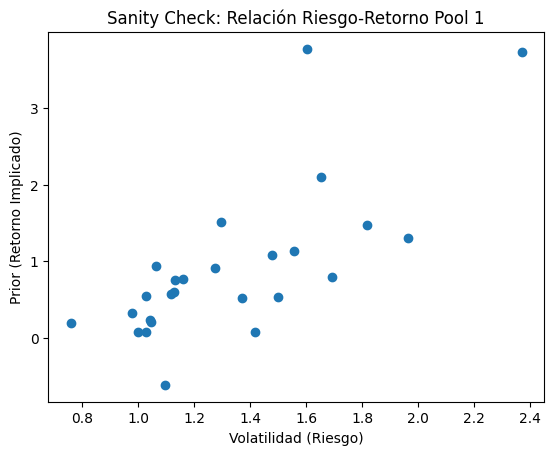

In [218]:
import matplotlib.pyplot as plt

# Tomamos el Pool 1 como ejemplo
volatilidad = np.sqrt(np.diag(S_p1)) # Volatilidad mensual

plt.scatter(volatilidad, priors_p1)
plt.xlabel("Volatilidad (Riesgo)")
plt.ylabel("Prior (Retorno Implicado)")
plt.title("Sanity Check: Relación Riesgo-Retorno Pool 1")
plt.show()

Paso 2: Convertiremos el target return a mensual, ya que lo tenemos anualizado. En consiguiente, calcularemos los vectores Q y las matrices P para los 3 pools:

In [219]:
import numpy as np

def construir_views_paso2(df_pool, priors_result, nombre_pool):
    print(f"--- Estructurando Views: {nombre_pool} ---")

    # Asegurar alineación: Usamos solo los tickers que sobrevivieron al Paso 1
    tickers_sync = priors_result.index.tolist()
    df_sync = df_pool.set_index('Ticker').reindex(tickers_sync)

    # Vector Q (Opiniones de rendimiento)
    # Convertimos de Anual a Mensual (Asumiendo retornos logarítmicos: / 12)
    # Si fueran retornos simples: (1 + View_Q)**(1/12) - 1
    q_mensual = df_sync['View_Q'] / 12
    Q = q_mensual.values

    # Matriz P (Picking Matrix)
    # Como tenemos una view por cada activo, P es una matriz identidad
    # Dimensiones: (N_views x N_activos) -> en este caso (N x N)
    P = np.eye(len(tickers_sync))

    print(f"Vector Q y Matriz P generados para {len(tickers_sync)} activos.")
    return P, Q

# Ejecutamos para los 3 pools
P_p1, Q_p1 = construir_views_paso2(pool_1, priors_p1, "Pool 1")
P_p2, Q_p2 = construir_views_paso2(pool_2, priors_p2, "Pool 2")
P_p3, Q_p3 = construir_views_paso2(pool_3, priors_p3, "Pool 3")

--- Estructurando Views: Pool 1 ---
Vector Q y Matriz P generados para 26 activos.
--- Estructurando Views: Pool 2 ---
Vector Q y Matriz P generados para 26 activos.
--- Estructurando Views: Pool 3 ---
Vector Q y Matriz P generados para 24 activos.


Paso 3: La matriz de incertidumbre. Habiendo definido el equilibrio del mercado y nuestras perspectivas personales, procederemos a cuantificar la confianza en nuestras opiniones mediante la matriz Ω (Omega), la cual actúa como un regulador de peso donde una Ω pequeña prioriza nuestras vistas y una Ω elevada mantiene la estructura del mercado. Para simplificar este proceso, adoptaremos el método de He & Litterman, el cual asume que la incertidumbre de nuestras opiniones es proporcional a la varianza de los activos a través del parámetro de escala τ (tau). Siguiendo los estándares de la industria financiera, fijaremos el valor de τ en 0.05, permitiéndonos modelar la incertidumbre mediante la expresión Ω=diag(P(τΣ)PT) para obtener un portafolio que equilibre de manera óptima la teoría de mercado con nuestras propias expectativas de rendimiento.

In [220]:
# Definimos Tau (Nivel de confianza: 0.05 es el estándar)
tau = 0.05

def calcular_omega_manual(S, P, tau):
    # Cálculo: diag(P * (tau * S) * P.T)
    # .values asegura que trabajemos con matrices de NumPy
    omega = np.diag(np.diag(P @ (tau * S.values) @ P.T))
    return omega

# Calculamos para tus 3 pools
omega_p1 = calcular_omega_manual(S_p1, P_p1, tau)
omega_p2 = calcular_omega_manual(S_p2, P_p2, tau)
omega_p3 = calcular_omega_manual(S_p3, P_p3, tau)

print("Matrices Omega calculadas manualmente con éxito.")

Matrices Omega calculadas manualmente con éxito.


Paso 4: Ejecución modelo Black Litterman

In [221]:
def obtener_posteriors(S, priors, P, Q, omega, tau, nombre):
    # Inicializamos el modelo
    bl = BlackLittermanModel(S, pi=priors, P=P, Q=Q, omega=omega, tau=tau)

    # MÉTODOS CORRECTOS SEGÚN TU VERSIÓN:
    # 1. Retornos ajustados (Posteriors)
    retornos_post = bl.bl_returns()

    # 2. Matriz de covarianza ajustada (Usamos .bl_cov())
    S_post = bl.bl_cov()

    print(f"Posteriors calculados exitosamente para {nombre}")
    return retornos_post, S_post

# Ejecución para tus 3 pools
try:
    post_ret_p1, post_S_p1 = obtener_posteriors(S_p1, priors_p1, P_p1, Q_p1, omega_p1, tau, "Pool 1")
    post_ret_p2, post_S_p2 = obtener_posteriors(S_p2, priors_p2, P_p2, Q_p2, omega_p2, tau, "Pool 2")
    post_ret_p3, post_S_p3 = obtener_posteriors(S_p3, priors_p3, P_p3, Q_p3, omega_p3, tau, "Pool 3")
except Exception as e:
    print(f"Error detectado: {e}")

print("\n--- PASO 4 COMPLETADO ---")
print("Top 5 Retornos Ajustados Pool 3:")
print(post_ret_p3.head(15))

Posteriors calculados exitosamente para Pool 1
Posteriors calculados exitosamente para Pool 2
Posteriors calculados exitosamente para Pool 3

--- PASO 4 COMPLETADO ---
Top 5 Retornos Ajustados Pool 3:
Ticker
8630.T           0.070962
7011.T           0.238263
8031.T           0.172975
8058.T           0.186965
8725.T           0.089043
5802.T           0.181813
5706.T           0.186685
8306.T           0.244672
ACTINVRB.MX      0.005917
BAFARB.MX        0.039883
BHARTIARTL.NS    0.116291
CBK.DE           0.111900
ANET             0.434247
CLH              0.102038
BAB.L            0.073869
dtype: float64


Paso 5 (Final): Usar la Frontera Eficiente de Markowitz para encontrar los pesos óptimos basándonos en los resultados del modelo Black-Litterman.

In [222]:
def optimizacion_final_minimo_1(post_ret, post_S, nombre_pool):
    # Filtro ESG y de retornos positivos
    activos_positivos = post_ret[post_ret > 0].index.tolist()
    ret_filtrados = post_ret.loc[activos_positivos]
    S_filtrada = post_S.loc[activos_positivos, activos_positivos]

    # Anualización
    ret_anual = ret_filtrados * 12
    S_anual = S_filtrada * 12

    try:
        # Markowitz con límites (Mín 1%, Máx 20%)
        ef = EfficientFrontier(ret_anual, S_anual, weight_bounds=(0.00, 0.18))
        ef.max_sharpe()

        # verbose=False para que la librería no imprima nada
        ret_p, vol_p, sharpe_p = ef.portfolio_performance(verbose=False)

        pesos = ef.clean_weights()
        return pd.Series(pesos), ret_p

    except Exception as e:
        return None, 0

# Ejecución
pesos_p3_final, ret_p3_final = optimizacion_final_minimo_1(post_ret_p3, post_S_p3, "Pool 3")

print(pesos_p3_final)
print(post_ret_p3)

8630.T           0.00000
7011.T           0.06172
8031.T           0.05655
8058.T           0.06672
8725.T           0.00000
5802.T           0.00000
5706.T           0.00000
8306.T           0.18000
ACTINVRB.MX      0.03664
BAFARB.MX        0.00000
BHARTIARTL.NS    0.15422
CBK.DE           0.02883
ANET             0.18000
CLH              0.00000
BAB.L            0.00000
ACGL             0.00000
BK               0.01726
CS.PA            0.06019
AAI.AX           0.01804
CHDRAUIB.MX      0.00000
CMM.AX           0.00000
BEZ.L            0.00000
CB               0.08805
dtype: float64
Ticker
8630.T           0.070962
7011.T           0.238263
8031.T           0.172975
8058.T           0.186965
8725.T           0.089043
5802.T           0.181813
5706.T           0.186685
8306.T           0.244672
ACTINVRB.MX      0.005917
BAFARB.MX        0.039883
BHARTIARTL.NS    0.116291
CBK.DE           0.111900
ANET             0.434247
CLH              0.102038
BAB.L            0.073869
ACGL         

In [223]:
import pandas as pd

# 1. Procesamos los Pesos (pesos_p3_final)
# Lo convertimos a DataFrame sin importar si es diccionario o Serie
if isinstance(pesos_p3_final, dict):
    df_pesos = pd.DataFrame(list(pesos_p3_final.items()), columns=['Ticker', 'Peso'])
else:
    # Si ya es una Serie de Pandas
    df_pesos = pd.DataFrame({'Ticker': pesos_p3_final.index, 'Peso': pesos_p3_final.values})

# Aseguramos escala decimal (0.20 en lugar de 20.0)
if df_pesos['Peso'].max() > 1.0:
    df_pesos['Peso'] = df_pesos['Peso'] / 100.0

# 2. Procesamos los Retornos (post_ret_p3)
# Convertimos la Serie a DataFrame y anualizamos (x12)
df_retornos = pd.DataFrame({
    'Ticker': post_ret_p3.index,
    'Retorno_Anual': post_ret_p3.values
})

# 3. Procesamos la Desvest (df_merged)
# Filtramos df_merged para obtener solo los tickers que nos interesan
df_vols = df_merged[df_merged['Ticker'].isin(post_ret_p3.index)][['Ticker', 'desvest_Anual']]

# 4. EL MERGE MAESTRO
# Unimos Pesos + Retornos + Desvest en un solo DataFrame
df_pool3_final = pd.merge(df_pesos, df_retornos, on='Ticker', how='inner')
df_pool3_final = pd.merge(df_pool3_final, df_vols, on='Ticker', how='inner')

# 5. Cálculo de Contribución y Limpieza
# Solo nos quedamos con las empresas que el optimizador sí eligió (Peso > 0)
df_pool3_final = df_pool3_final[df_pool3_final['Peso'] > 0].sort_values(by='Peso', ascending=False)

# Añadimos la contribución individual para que veas quién "pesa" más en el rendimiento
df_pool3_final['Contribucion_Ret'] = df_pool3_final['Peso'] * df_pool3_final['Retorno_Anual']

print("--- DATAFRAME CONSOLIDADO: POOL 3 ---")
print(df_pool3_final[['Ticker', 'Peso', 'Retorno_Anual', 'desvest_Anual', 'Contribucion_Ret']])

# Validación final de los totales
ret_total_pool = df_pool3_final['Contribucion_Ret'].sum()
print(f"\nRetorno Esperado Total del Pool 3: {ret_total_pool:.2%}")

--- DATAFRAME CONSOLIDADO: POOL 3 ---
           Ticker     Peso  Retorno_Anual  desvest_Anual  Contribucion_Ret
7          8306.T  0.18000       0.244672       0.241234          0.044041
12           ANET  0.18000       0.434247       0.387164          0.078164
10  BHARTIARTL.NS  0.15422       0.116291       0.193475          0.017934
25             CB  0.08805       0.128366       0.198435          0.011303
3          8058.T  0.06672       0.186965       0.274535          0.012474
1          7011.T  0.06172       0.238263       0.330710          0.014706
20          CS.PA  0.06019       0.143019       0.202996          0.008608
2          8031.T  0.05655       0.172975       0.232894          0.009782
8     ACTINVRB.MX  0.03664       0.005917       0.108161          0.000217
11         CBK.DE  0.02883       0.111900       0.336263          0.003226
21         AAI.AX  0.01804       0.030447       0.383262          0.000549
18             BK  0.01726       0.170875       0.238689      

A continuación, agregaremos la deuda privada (3 bonos corporativos estadounidenses de Barrick y Life Way) y deuda libre de riesgo, bonos a 10 años de FRED y Bonos M.

In [224]:
# Armamos el Portafolio Maestro (Asset Allocation)
master_data = {
    'Componente': [
        'Risk Free USA (10Y)',
        'Risk Free México (Bono M)',
        'Bono Barrick ABX.GQ',
        'Bono Barrick ABX.GP',
        'Bono Life Way CHRC',
        'Pool 3 (Equity BL)'
    ],
    'Peso': [0.075, 0.075, 0.0333, 0.0333, 0.0334, 0.75],
    'Retorno_Anual': [
        0.0432,           # 4.32% USA
        0.0850,           # 8.50% MX
        0.057,            # 5.70% Barrick 1
        0.057,            # 5.70% Barrick 2
        0.075,            # 7.50% Life Way
        ret_total_pool    # retorno de portafolio renta variable
    ]
}

df_Master = pd.DataFrame(master_data)

# Cálculo de la Contribución y Retorno Total
#df_Master['Contribucion'] = df_Master['Peso'] * df_Master['Retorno_Anual']
#retorno_total_fondo = df_Master['Contribucion'].sum()

print("\n--- DISTRIBUCIÓN FINAL DEL FAMILY OFFICE FUND ---")
print(df_Master[['Componente', 'Peso', 'Retorno_Anual']])


--- DISTRIBUCIÓN FINAL DEL FAMILY OFFICE FUND ---
                  Componente    Peso  Retorno_Anual
0        Risk Free USA (10Y)  0.0750       0.043200
1  Risk Free México (Bono M)  0.0750       0.085000
2        Bono Barrick ABX.GQ  0.0333       0.057000
3        Bono Barrick ABX.GP  0.0333       0.057000
4         Bono Life Way CHRC  0.0334       0.075000
5         Pool 3 (Equity BL)  0.7500       0.212802


In [225]:
# Calculamos la columna de contribución individual
df_Master['Contribucion'] = df_Master['Peso'] * df_Master['Retorno_Anual']

# Sumamos todas las contribuciones para obtener el retorno del fondo
retorno_total_portafolio_mixto = df_Master['Contribucion'].sum()

print("--- RESULTADO FINAL DEL FONDO ---")
print(f"Retorno Esperado Anual de portafolio mixto: {retorno_total_portafolio_mixto:.2%}")

--- RESULTADO FINAL DEL FONDO ---
Retorno Esperado Anual de portafolio mixto: 17.55%


Ya que tenemos el portafolio con: renta variable, renta fija corporativa e instrumentos libre de riesgo, calcularemos el VaR diario, semanal y mensual. Tomando en cuenta que tenemos $20,000,000 MXN. Evaluaremos con 95% de confianza.

In [232]:
# LIMPIEZA DE DUPLICADOS ---
# Eliminamos cualquier ticker repetido (como BK) antes de procesar
df_pool3_limpio = df_pool3_final.drop_duplicates(subset='Ticker', keep='first').copy()

# DEUDA Y RISK FREE ---
# Tomamos los primeros 5 componentes de df_Master
df_deuda_final = df_Master.iloc[0:5].copy()

# Asignamos volatilidades proxy
vols_deuda = [0.00, 0.00, 0.10, 0.10, 0.14]
df_deuda_final['desvest_Anual'] = vols_deuda
df_deuda_final = df_deuda_final.rename(columns={'Componente': 'Ticker'})

# EQUITY (POOL 3) ---
# Usamos el dataframe ya limpio sin repetidos
df_equity_final = df_pool3_limpio[['Ticker', 'Peso', 'Retorno_Anual', 'desvest_Anual']].copy()

# Ajustamos el peso global (Peso interno * 0.65)
df_equity_final['Peso'] = df_equity_final['Peso'] * 0.65

# CONCATENACIÓN Y CÁLCULOS ---
df_Portafolio_Global = pd.concat([df_deuda_final, df_equity_final], ignore_index=True)

# Contribuciones
df_Portafolio_Global['Contribucion_Ret'] = df_Portafolio_Global['Peso'] * df_Portafolio_Global['Retorno_Anual']
df_Portafolio_Global['Varianza_Ponderada'] = (df_Portafolio_Global['Peso']**2) * (df_Portafolio_Global['desvest_Anual']**2)

# Imprimimos el resultado final
print("--- DATAFRAME MAESTRO: FAMILY OFFICE FUND (SIN DUPLICADOS) ---")
print(df_Portafolio_Global[['Ticker', 'Peso', 'Retorno_Anual', 'desvest_Anual', 'Contribucion_Ret']])

# Verificación de Totales
ret_final = df_Portafolio_Global['Contribucion_Ret'].sum()
vol_final = np.sqrt(df_Portafolio_Global['Varianza_Ponderada'].sum())
suma_pesos = df_Portafolio_Global['Peso'].sum()

print(f"\nRESUMEN EJECUTIVO DEL FONDO:")
print(f"Suma Total de Pesos: {suma_pesos:.4f}")
print(f"Retorno Esperado Total: {ret_final:.2%}")
print(f"Volatilidad Total (Desvest): {vol_final:.2%}")

--- DATAFRAME MAESTRO: FAMILY OFFICE FUND (SIN DUPLICADOS) ---
                       Ticker      Peso  Retorno_Anual  desvest_Anual  \
0         Risk Free USA (10Y)  0.075000       0.043200       0.000000   
1   Risk Free México (Bono M)  0.075000       0.085000       0.000000   
2         Bono Barrick ABX.GQ  0.033300       0.057000       0.100000   
3         Bono Barrick ABX.GP  0.033300       0.057000       0.100000   
4          Bono Life Way CHRC  0.033400       0.075000       0.140000   
5                      8306.T  0.117000       0.244672       0.241234   
6                        ANET  0.117000       0.434247       0.387164   
7               BHARTIARTL.NS  0.100243       0.116291       0.193475   
8                          CB  0.057233       0.128366       0.198435   
9                      8058.T  0.043368       0.186965       0.274535   
10                     7011.T  0.040118       0.238263       0.330710   
11                      CS.PA  0.039123       0.143019       

Cálculo de Value at Risk: diario, semanal y mensual.

In [233]:
#Definimos las variables necesarias (Basadas en tus cálculos anteriores)
valor_portafolio = 20_000_000
z_score = 1.645  # Para un nivel de confianza del 95%
mu = ret_final    # El retorno total que calculamos (aprox 0.2412)
sigma = vol_final # La volatilidad total que calculamos (aprox 0.1916)

#Definimos los periodos (días hábiles)
periodos = {
    'Diario': 1,
    'Semanal': 5,
    'Mensual': 21
}

print(f"--- ANÁLISIS DE RIESGO: VaR 95% (Capital: ${valor_portafolio:,.2f} MXN) ---")

for nombre, t in periodos.items():
    # Escalamos media y desviación estándar
    # Dividimos entre 252 porque son los días laborales del año
    mu_t = mu * (t / 252)
    sigma_t = sigma * np.sqrt(t / 252)

    # Fórmula del VaR Paramétrico: V * (Z * sigma_t - mu_t)
    var_monto = valor_portafolio * (z_score * sigma_t - mu_t)

    # El max(0, ...) es por si el retorno es tan alto que el riesgo "desaparece"
    print(f"VaR {nombre}: ${max(0, var_monto):,.2f} MXN")

--- ANÁLISIS DE RIESGO: VaR 95% (Capital: $20,000,000.00 MXN) ---
VaR Diario: $118,066.75 MXN
VaR Semanal: $231,433.42 MXN
VaR Mensual: $347,576.86 MXN


Ahora sacamos el Conditional VaR o Expected Shortfall

In [234]:
#Variables base del fondo
valor_portafolio = 20_000_000
alfa = 0.05  # Nivel de significancia (1 - 0.95)

# Parámetros de la Normal Estándar
# z_score para el 95% es -1.645
z_score = norm.ppf(alfa)
# Densidad de la curva (pdf) en ese punto exacto
pdf_z = norm.pdf(z_score)

# Definimos los periodos (días hábiles)
periodos = {
    'Diario': 1,
    'Semanal': 5,
    'Mensual': 21
}

print(f"--- RIESGO: CVaR 95% (Capital: ${valor_portafolio:,.2f} MXN) ---")
print("Este valor representa la pérdida PROMEDIO en el peor 5% de los escenarios.")

for nombre, t in periodos.items():
    # Escalamos media y desvest (anual -> t)
    mu_t = ret_final * (t / 252)
    sigma_t = vol_final * np.sqrt(t / 252)

    # Fórmula del CVaR Paramétrico (Pérdida esperada en la cola)
    # CVaR = - (mu_t - sigma_t * (pdf_z / alfa))
    cvar_unitario = -(mu_t - sigma_t * (pdf_z / alfa))
    cvar_monto = valor_portafolio * cvar_unitario

    print(f"CVaR {nombre}: ${max(0, cvar_monto):,.2f} MXN")

--- RIESGO: CVaR 95% (Capital: $20,000,000.00 MXN) ---
Este valor representa la pérdida PROMEDIO en el peor 5% de los escenarios.
CVaR Diario: $151,039.75 MXN
CVaR Semanal: $305,163.28 MXN
CVaR Mensual: $498,678.11 MXN
